🧮 Assignment: K-Nearest Neighbors (KNN) Algorithm using Python

In [4]:
# -----------------------------------------------------------
# Assignment: K-Nearest Neighbors (KNN) Algorithm using Python
# -----------------------------------------------------------

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris         # ✅ FIXED: Import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
# -----------------------------------------------------------
# Step 1: Load Dataset
# -----------------------------------------------------------

iris = load_iris()   # ✅ Now it will work correctly

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("🔹 First 5 rows of dataset:")
print(df.head())


🔹 First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [7]:
# -----------------------------------------------------------
# Step 2: Split Dataset into Train and Test
# -----------------------------------------------------------

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------------------------------------
# Step 3: Feature Scaling
# -----------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------------------------------
# Step 4: Train KNN Model
# -----------------------------------------------------------

knn = KNeighborsClassifier(n_neighbors=5)  # Using k=5
knn.fit(X_train_scaled, y_train)

# -----------------------------------------------------------
# Step 5: Make Predictions
# -----------------------------------------------------------

y_pred = knn.predict(X_test_scaled)

In [8]:
# -----------------------------------------------------------
# Step 6: Evaluate Model Performance
# -----------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print("\n🔹 Confusion Matrix:\n", cm)

report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\n🔹 Classification Report:\n", report)


✅ Model Accuracy: 100.00%

🔹 Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

🔹 Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



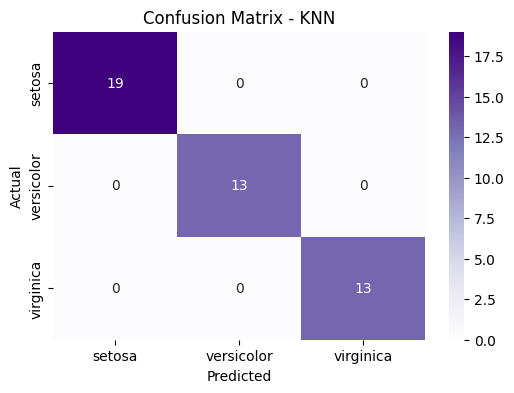

In [9]:
# -----------------------------------------------------------
# Step 7: Visualization
# -----------------------------------------------------------

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

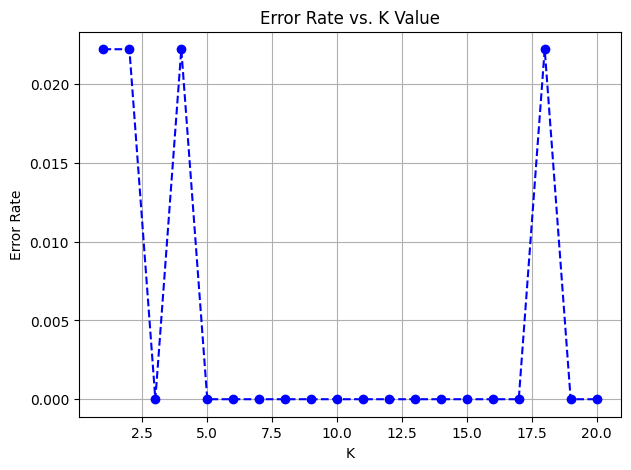

In [10]:
# -----------------------------------------------------------
# Step 8: Find the Best K Value
# -----------------------------------------------------------

error_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_k != y_test))

plt.figure(figsize=(7,5))
plt.plot(range(1,21), error_rate, marker='o', linestyle='--', color='b')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()